In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Chargement des datasets
evaluation = pd.read_csv("Datasets/assessments.csv") 
notes_etudiants = pd.read_csv("Datasets/studentAssessment.csv")
profil_etudiants = pd.read_csv("Datasets/studentInfo.csv")
inscription = pd.read_csv("Datasets/studentRegistration.csv")
clic_platforme_etudiant = pd.read_csv("Datasets/studentVle.csv ") # Fichier qui enregistre chaque clic de chaque etudaint sur la plateforme
materiel_pedagogique = pd.read_csv("Datasets/vle.csv")  #Repertoire de toutes les ressources disponible sur la plateforme


<h3 style = "background : blue; width : 800px">
    Analyse du dataset evaluation
</h3>

In [11]:
evaluation.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [17]:
evaluation.shape

(206, 6)

In [12]:
evaluation.columns

Index(['code_module', 'code_presentation', 'id_assessment', 'assessment_type',
       'date', 'weight'],
      dtype='str')

In [15]:
# Renommer les colonnes en français
evaluation = evaluation.rename(columns={
    'code_module': 'code_module',
    'code_presentation': 'code_presentation',
    'id_assessment': 'id_evaluation',
    'assessment_type': 'type_evaluation',
    'date': 'jours_limite_rendu',  # Nombre de jours depuis le début du cours pour rendre le devoir
    'weight': 'coefficient'         # Poids de l'évaluation sur 100
})
evaluation.columns

Index(['code_module', 'code_presentation', 'id_evaluation', 'type_evaluation',
       'jours_limite_rendu', 'coefficient'],
      dtype='str')

In [16]:
evaluation.info()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code_module         206 non-null    str    
 1   code_presentation   206 non-null    str    
 2   id_evaluation       206 non-null    int64  
 3   type_evaluation     206 non-null    str    
 4   jours_limite_rendu  195 non-null    float64
 5   coefficient         206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 12.0 KB


In [20]:
val_manque = evaluation.isnull().mean()*100
val_manque.sort_values(ascending=False).round(2)

jours_limite_rendu    5.34
code_module           0.00
code_presentation     0.00
id_evaluation         0.00
type_evaluation       0.00
coefficient           0.00
dtype: float64

In [22]:
# Le dataset contient des valeurs manquantes dans la colonne "jours_limite_rendu" (date de rendu de l'évaluation) environ 5, 34% de valeur manquates. Il est important de traiter ces valeurs manquantes avant d'effectuer toute analyse.

In [27]:
evaluation["type_evaluation"].value_counts()

type_evaluation
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

In [28]:
# Remplacer les types d'évaluations par leurs noms en français
evaluation['type_evaluation'] = evaluation['type_evaluation'].replace({
    'TMA': 'Devoir écrit (Tuteur)',
    'CMA': 'Quiz en ligne (Ordinateur)',
    'Exam': 'Examen final'
})

In [29]:
evaluation[evaluation['jours_limite_rendu'].isna()]["type_evaluation"].value_counts()

type_evaluation
Examen final    11
Name: count, dtype: int64

J'ai tester de voir pour quelle type d'évaluation les valeurs manquantes sont présentes. 
Il s'avère que les valeurs manquantes sont présentes uniquement pour les évaluations de type "Examen final". 
Cela peut être dû au fait que la date limite de rendu pour les examens finaux n'est pas applicable,
  car ils ont lieu à une date fixe et ne sont pas soumis à un délai de rendu comme 
les devoirs ou les quiz.

- `Petit visualisation de la répartition des types d'évaluations`

Text(0.5, 1.0, "Répartition des types d'évaluations")

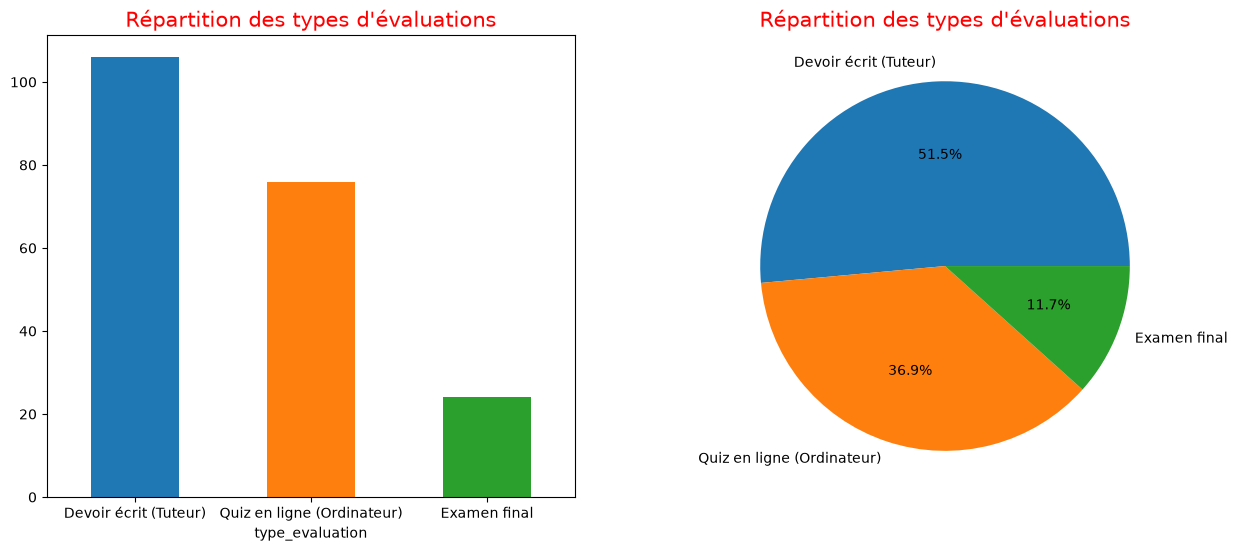

In [49]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
evaluation["type_evaluation"].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xticks(rotation=0)
plt.title("Répartition des types d'évaluations",color = 'red', size =15)

#Diagrame circulaire pour visualiser la répartition des types d'évaluations
plt.subplot(1, 2, 2)
plt.pie(evaluation["type_evaluation"].value_counts(), labels=evaluation["type_evaluation"].value_counts().index, autopct='%1.1f%%',colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Répartition des types d'évaluations", color = 'red', size =15)

<p align = "center", style = "color : yellow">Interpretation du graphe : </p>

- `Un volume d'effort massif sur les devoirs écrits` : Plus de la moitié des actions d'évaluation (51,5 %) concernent des devoirs rendus à un tuteur. Cela signifie que la majeure partie de la charge de travail demandée aux étudiants et de leur production écrite se concentre sur les TMA.

- `Une régularité marquée par les quiz` : Avec 36,9 % des validations, les quiz en ligne montrent que les étudiants se connectent très fréquemment pour faire de petites évaluations automatisées en continu.

- `La rareté de l'examen final` : Les examens ne représentent que 11,7 % des lignes. C'est tout à fait logique : alors qu'un étudiant rend plusieurs devoirs et fait de nombreux quiz tout au long de l'année, il ne passe l'examen final qu'une seule fois par module.

<h3 style = "background : blue; width : 800px">
    Analyse du dataset notes
</h3>

In [50]:
notes_etudiants.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [53]:
notes_etudiants.shape

(173912, 5)

Le dataset notes_etudiants contient 173912 lignes et 5 colonnes. Il est important de vérifier les valeurs manquantes dans ce dataset avant de procéder à l'analyse.

In [55]:

# Renommer les colonnes en français
notes_etudiants.rename(columns={
    'id_assessment': 'id_evaluation',
    'id_student': 'id_etudiant',
    'date_submitted': 'jours_avant_remise',
    'is_banked': 'note_transferee',
    'score': 'note'
}, inplace=True)

In [56]:
notes_etudiants.head()

,id_evaluation,id_etudiant,jours_avant_remise,note_transferee,note
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


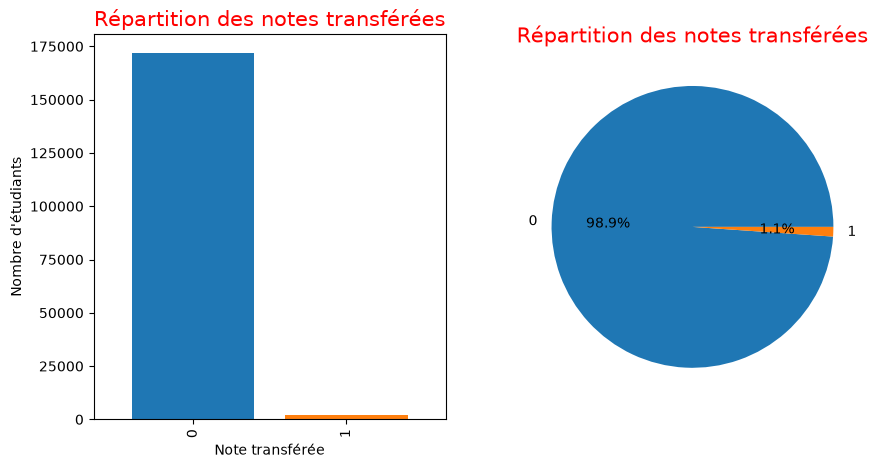

In [72]:
#Veridication des valeurs manquantes dans le dataset notes_etudiants
notes_etudiants.info()

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id_evaluation       173912 non-null  int64  
 1   id_etudiant         173912 non-null  int64  
 2   jours_avant_remise  173912 non-null  int64  
 3   note_transferee     173912 non-null  int64  
 4   note                173912 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [61]:
note_mank = notes_etudiants.isnull().mean()*100
note_mank.sort_values(ascending=False).round(3)

note                  0.099
id_evaluation         0.000
id_etudiant           0.000
jours_avant_remise    0.000
note_transferee       0.000
dtype: float64

il y'a envirion `0,099%` de valeur manquante dans la variable note ,
- Dans le domaine de l'éducation en ligne, si un étudiant a une note manquante pour un devoir obligatoire, cela signifie très souvent qu'il a rendu copie blanche, qu'il a raté la date limite, ou qu'il a déjà abandonné le cours à ce moment-là. Lui attribuer la note de 0 reflète donc parfaitement sa situation académique réelle à cet instant.

bien comme dans tout projet de datascience nos donnes manquantes sont trop petit alors je vais remplacer ces notes manquantes  par 0.

In [62]:
notes_etudiants["note"] = notes_etudiants["note"].fillna(0)  # Remplacer les valeurs manquantes par 0

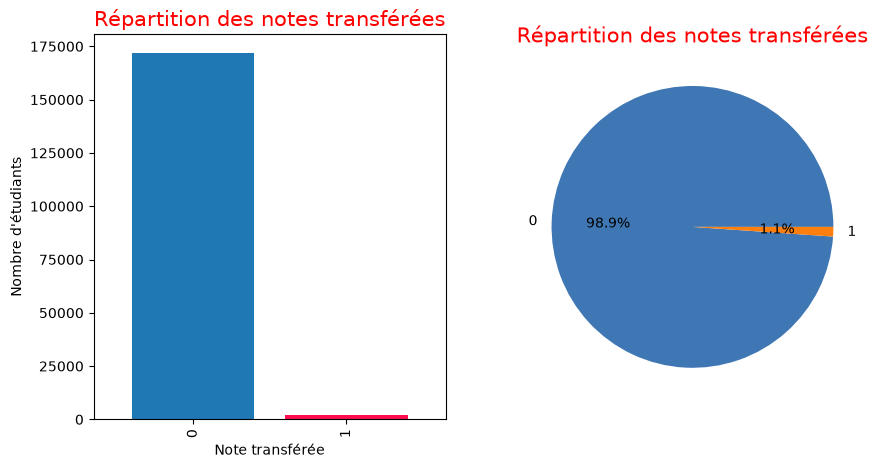

In [76]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
notes_etudiants["note_transferee"].value_counts().plot(kind='bar', width=0.8, color=['#1f77b4', "#ff0e4e"])
plt.title("Répartition des notes transférées", color = 'red', size =15)
plt.xlabel("Note transférée")
plt.ylabel("Nombre d'étudiants")

plt.subplot(1,2,2)
plt.pie(notes_etudiants["note_transferee"].value_counts(), labels=notes_etudiants["note_transferee"].value_counts().index, autopct='%1.1f%%',colors=['#3f77b4', '#ff7f0e'])
plt.title("Répartition des notes transférées", color = 'red', size =15)
plt.show()

 **Analyse métier :** \
Le graphique montre que **98,9 %** des évaluations concernent le parcours classique (les étudiants composent normalement ce semestre). 
À l'inverse, **1,1 %** des lignes représentent des notes transférées. Cela indique qu'une petite minorité d'étudiants a déjà validé ces compétences lors d'une session précédente et conserve son avantage pour alléger sa charge de travail actuelle.
